# EDA on MPG dataset

### Topics covered:
- Bivariate Analysis

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

data_file = "data_MPG.csv"

C:\Users\hi\AppData\Local\Temp\ipykernel_18464\568279515.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
df = pd.read_csv(data_file)
# print(df.sample(5))
print(df.head(5))

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


## Preliminaries

### **Data Cleaning & Preparation** (Same as before)


In [4]:
# STEP1: 

print(df.isnull().sum())

# STEP2:
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean()) # mean
print(df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [5]:
# Handle data types (`horsepower` might need conversion to uint8 because values are in the range 0-255).

# df['horsepower'] = df['horsepower'].astype("uint8")
df['horsepower'] = pd.to_numeric(df['horsepower'], downcast='integer') # better

# df['model_year'] = df['model_year'].astype("uint8")
df['model_year'] = pd.to_numeric(df['model_year'], downcast='integer') # better

df['cylinders']  = df['cylinders'].astype("category")
df['origin']     = df['origin'].astype("category")

In [6]:
# There are outliers. I am choosing to cap them....there are many other options too, but I am keeping it simple
columns = ["mpg", "horsepower", "acceleration"]
for col in columns:
    lower_cap = df[col].quantile(0.05)
    upper_cap = df[col].quantile(0.95)
    df[col] = df[col].clip(lower=lower_cap, upper=upper_cap)


### **Bivariate Analysis**

* **Continuous vs. Continuous**:

  * Scatter plot: `mpg` vs `weight` (usually negative correlation).
  * Scatter plot: `mpg` vs `horsepower`.
  * Scatter plot: `mpg` vs `displacement`.
* **Categorical vs. Continuous**:

  * Boxplots: `mpg` across different `cylinders`.
  * Boxplots: `mpg` across different `origin`.
  * Trend of `mpg` over `model_year`.

---



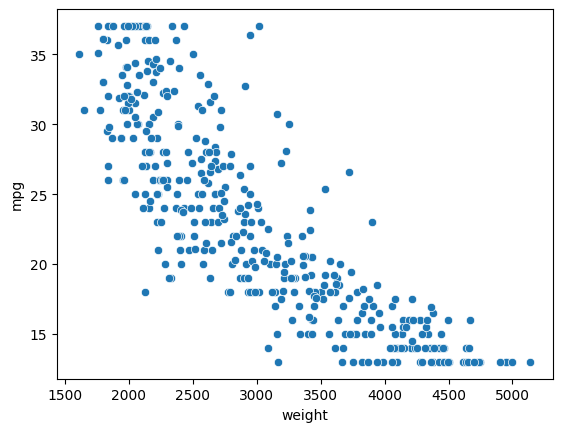

In [7]:
# step1: scatterplot of mpg vs weight
sns.scatterplot(x="weight", y="mpg", data=df)
plt.show()

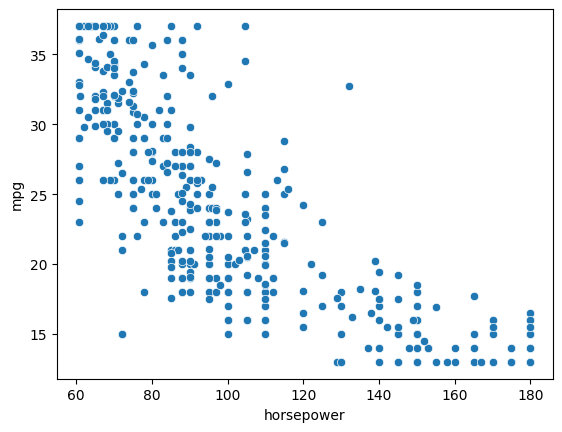

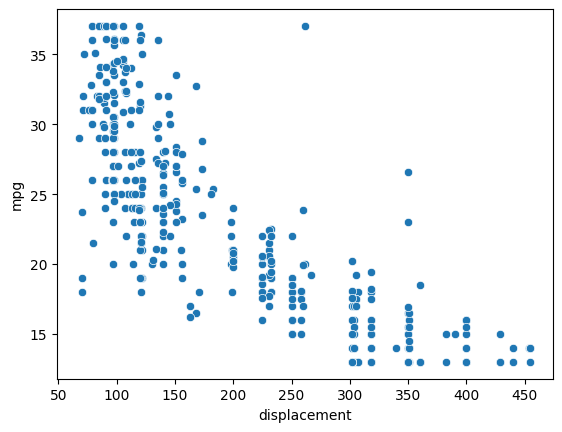

In [8]:
# step2: scatterplot between mpg and horsepower/displacement
columns = [ "horsepower", "displacement"]

for col in  columns:
    sns.scatterplot(x=col, y="mpg", data=df)
    plt.show()
    print("\n\n")

# Observ: As HP or displacement goes up, MPG goes down.

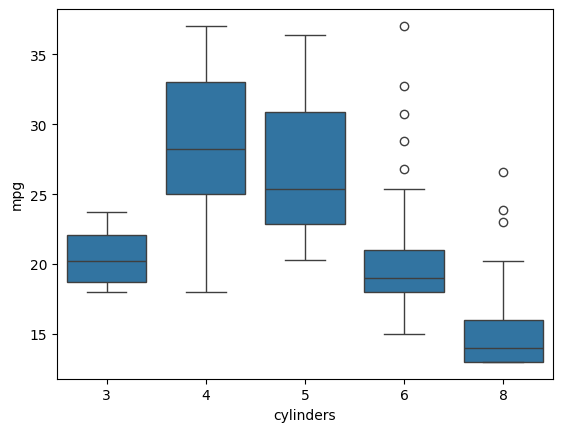

In [9]:
# boxplot between cylinders and mpg

sns.boxplot(data=df, x="cylinders", y="mpg")
plt.show()

# observ: 1) It appears that 4 or 5 cylinder engine give better mileage. If cyl. is too low or too high, not good.
# 2) For cyl. 8 , the MPG is shameful/pathetic



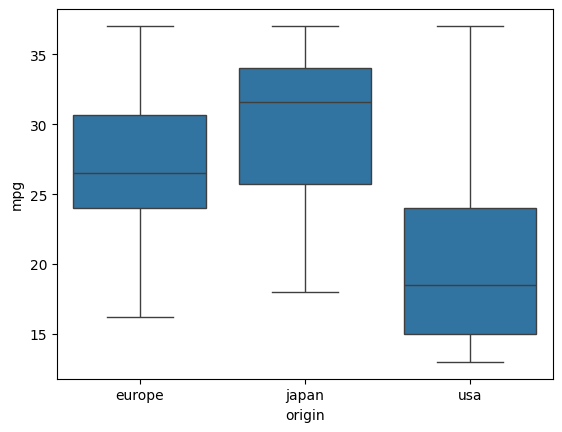

In [10]:
# boxplot between origin and mpg

sns.boxplot(data=df, x="origin", y="mpg")
plt.show()

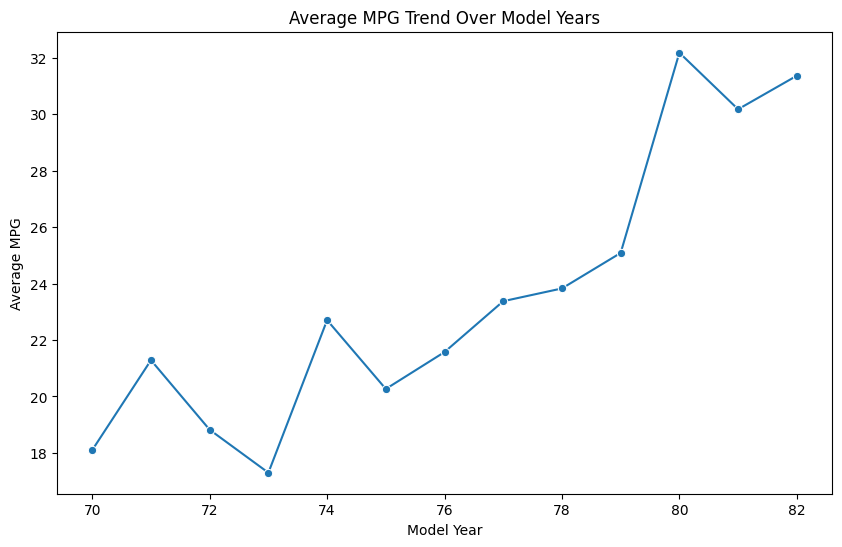

In [11]:
# step1: trend of MPG over the years

# Group by model_year and take mean mpg
yearly_trend = df.groupby("model_year")["mpg"].mean().reset_index()

# Plot
plt.figure(figsize=(10,6))
sns.lineplot(x="model_year", y="mpg", data=yearly_trend, marker="o")

plt.title("Average MPG Trend Over Model Years")
plt.xlabel("Model Year")
plt.ylabel("Average MPG")
plt.show()

# observ: average MPG has increasing trend

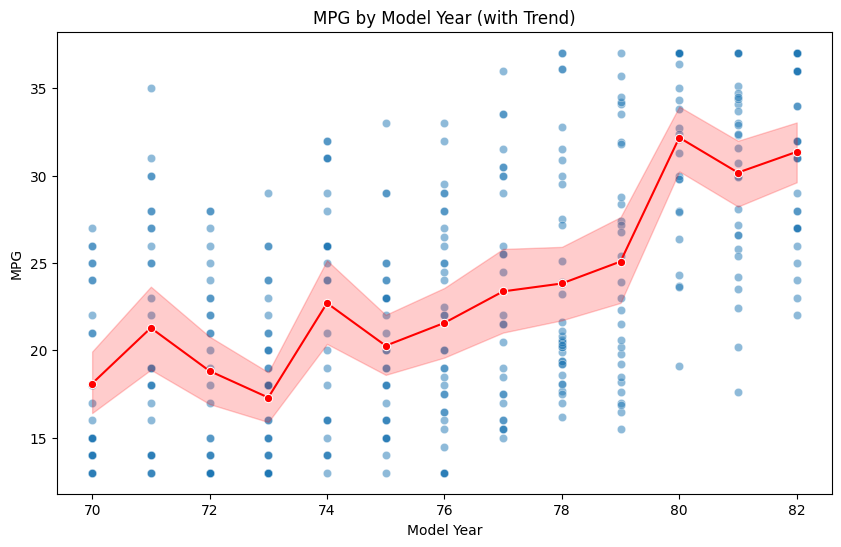

In [12]:
# step2: Lets add more info to trend of MPG over the years

plt.figure(figsize=(10,6))
sns.scatterplot(x="model_year", y="mpg", data=df, alpha=0.5)
sns.lineplot(x="model_year", y="mpg", data=df, estimator="mean", color="red", marker="o")

plt.title("MPG by Model Year (with Trend)")
plt.xlabel("Model Year")
plt.ylabel("MPG")
plt.show()

# obser: Each point = a car.
# Red line = average mpg trend.

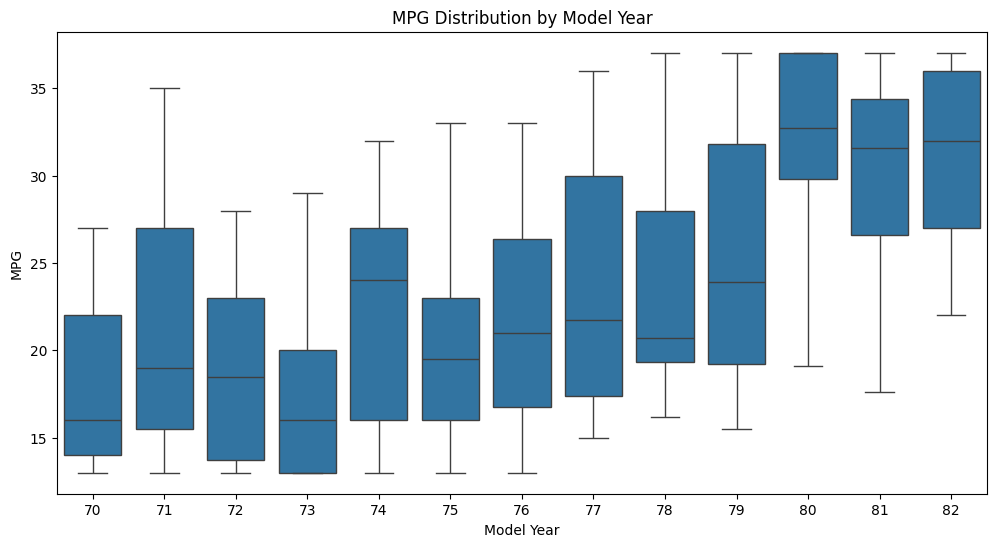

In [13]:
# Boxplot between model year and mpg
plt.figure(figsize=(12,6))
sns.boxplot(x="model_year", y="mpg", data=df)

plt.title("MPG Distribution by Model Year")
plt.xlabel("Model Year")
plt.ylabel("MPG")
plt.show()

# observ: I am not happy with boxplot